# Análisis de Sentimientos: Comentarios sobre Obesidad

Este notebook explora los sentimientos en comentarios relacionados con obesidad clasificados con vLLM y Llama-3.2-3B-Instruct.

## Objetivos del Análisis:
1. **Distribución de sentimientos** - Visualizar la proporción de comentarios positivos, negativos y neutros
2. **Palabras más frecuentes** - Identificar términos comunes por cada categoría de sentimiento
3. **Análisis TF-IDF** - Encontrar las palabras más significativas y distintivas de cada grupo
4. **Identificación de insultos** - Detectar y analizar las expresiones ofensivas más frecuentes
5. **Relación longitud-sentimiento** - Analizar si la extensión de los comentarios se relaciona con el sentimiento
6. **Patrones temporales** - Explorar distribución temporal y engagement

---

## 1. Carga de Datos y Librerías

Importamos las librerías necesarias y cargamos el dataset clasificado.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter
import ast
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
# Cargar el dataset clasificado
data_path = "practicos/base_obesidad_classified.csv"
df = pd.read_csv(data_path)

print(f"📊 Dataset cargado exitosamente!")
print(f"📝 Total de comentarios: {len(df):,}")
print(f"📋 Columnas disponibles: {list(df.columns)}")
print(f"\n🔍 Primeras filas:")
df.head()

📊 Dataset cargado exitosamente!
📝 Total de comentarios: 10,977
📋 Columnas disponibles: ['id_str', 'date', 'rawContent', 'replyCount', 'retweetCount', 'likeCount', 'quoteCount', 'conversationId', 'hashtags', 'viewCount', 'pcia', 'mes', 'user_id', 'cleaned_content', 'is_valid', 'sentiment']

🔍 Primeras filas:


,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id,cleaned_content,is_valid,sentiment
0,1747300752475730129,2024-01-16 16:52:17,Boluda ahí dice que yo debería pesar 43kg eso ...,1,0,1.0,0,1747290800474476846,[],18.0,['argentina'],1,0,Boluda ahí dice que yo debería pesar 43kg eso ...,True,NEGATIVO
1,1747297783743197385,2024-01-16 16:40:29,"Jugador de +30 años, vendehumo, con tendencias...",0,0,1.0,0,1747268216882102581,[],21.0,['buenos aires'],1,1,"Jugador de +30 años, vendehumo, con tendencias...",True,NEGATIVO
2,1747295025363341318,2024-01-16 16:29:31,"yo, re pesada mal: ✨EL UNIVERSO CONSPIRA A MI ...",0,0,0.0,0,1747295025363341318,[],54.0,['buenos aires'],1,2,"yo, re pesada mal: EL UNIVERSO CONSPIRA A MI F...",True,NEGATIVO
3,1747240401788907570,2024-01-16 12:52:28,Me puse una cartera usada que me regalaron y t...,12,11,4074.0,9,1747240401788907570,[],61351.0,[],1,3,Me puse una cartera usada que me regalaron y t...,True,NEUTRO
4,1747292672232931781,2024-01-16 16:20:10,La tabla de mi pediatra cuando tenia 6 años y ...,0,0,0.0,0,1747292672232931781,[],98.0,['buenos aires'],1,4,La tabla de mi pediatra cuando tenia 6 años y ...,True,NEGATIVO


## 2. Distribución de Sentimientos

Analizamos la distribución de sentimientos en los comentarios clasificados.

📊 DISTRIBUCIÓN DE SENTIMIENTOS
NEGATIVO: 9,007 comentarios (82.1%)
NEUTRO: 1,871 comentarios (17.0%)
POSITIVO: 99 comentarios (0.9%)


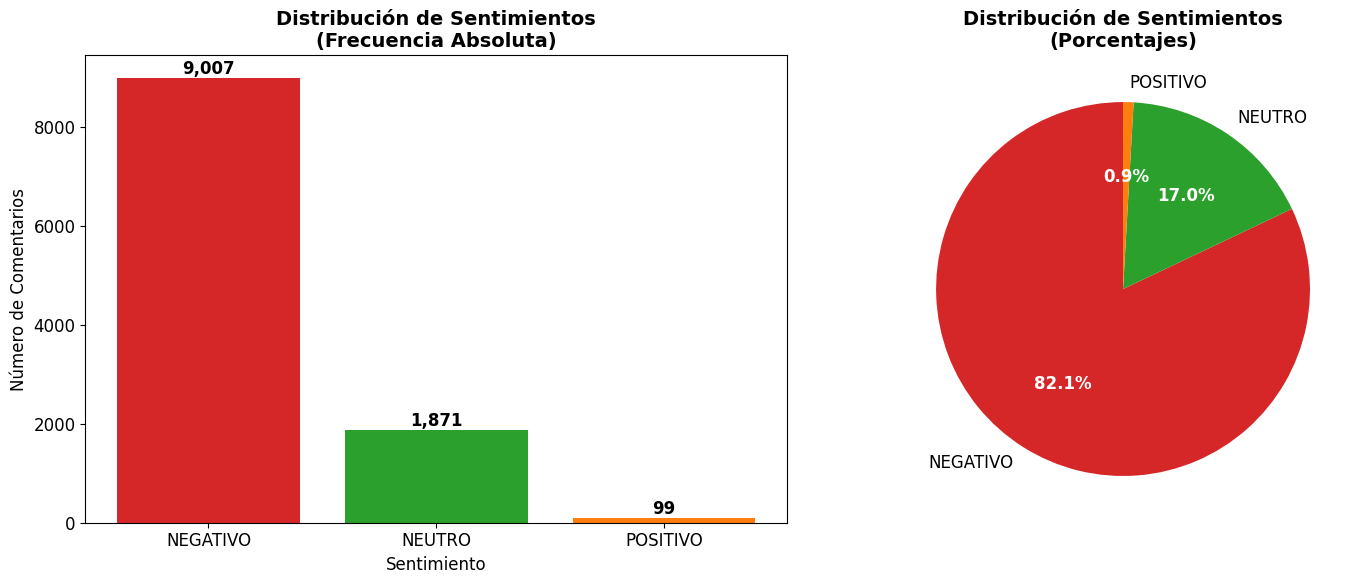

In [10]:
# Análisis de distribución de sentimientos
sentiment_counts = df['sentiment'].value_counts()
sentiment_percentages = df['sentiment'].value_counts(normalize=True) * 100

print("📊 DISTRIBUCIÓN DE SENTIMIENTOS")
print("=" * 40)
for sentiment in sentiment_counts.index:
    count = sentiment_counts[sentiment]
    percentage = sentiment_percentages[sentiment]
    print(f"{sentiment}: {count:,} comentarios ({percentage:.1f}%)")

# Crear gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras
colors = ['#d62728', '#2ca02c', '#ff7f0e']  # Rojo, Verde, Naranja
bars = ax1.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
ax1.set_title('Distribución de Sentimientos\n(Frecuencia Absoluta)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentimiento')
ax1.set_ylabel('Número de Comentarios')

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# Gráfico de pastel
wedges, texts, autotexts = ax2.pie(sentiment_counts.values, 
                                   labels=sentiment_counts.index,
                                   autopct='%1.1f%%',
                                   colors=colors,
                                   startangle=90)
ax2.set_title('Distribución de Sentimientos\n(Porcentajes)', fontsize=14, fontweight='bold')

# Mejorar formato del pie chart
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

## 3. Análisis de Palabras Más Frecuentes

Exploramos las palabras más comunes en cada categoría de sentimiento.

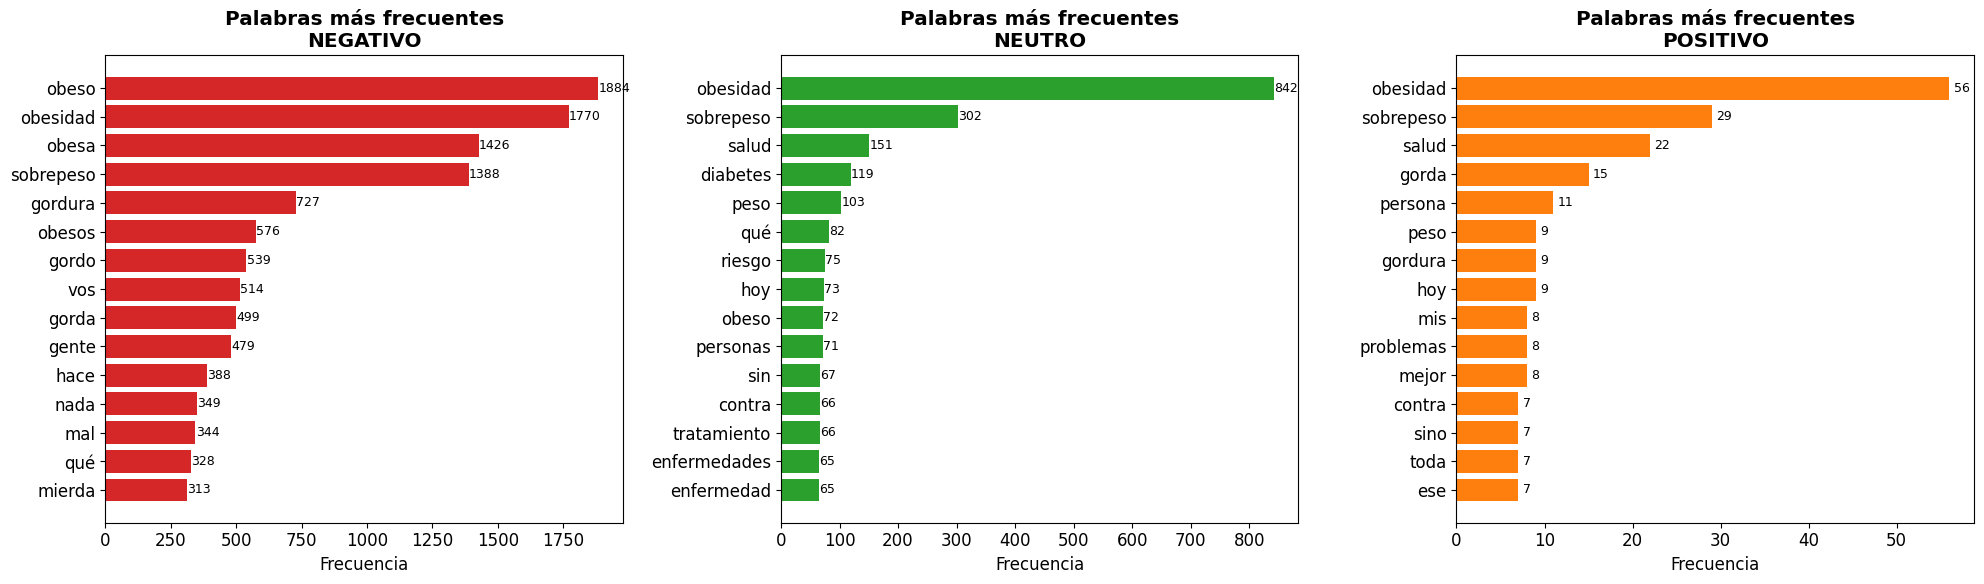


📝 TOP 10 PALABRAS MÁS FRECUENTES POR SENTIMIENTO

🔸 NEGATIVO:
   1. obeso           (1884 veces)
   2. obesidad        (1770 veces)
   3. obesa           (1426 veces)
   4. sobrepeso       (1388 veces)
   5. gordura         (727 veces)
   6. obesos          (576 veces)
   7. gordo           (539 veces)
   8. vos             (514 veces)
   9. gorda           (499 veces)
  10. gente           (479 veces)

🔸 NEUTRO:
   1. obesidad        (842 veces)
   2. sobrepeso       (302 veces)
   3. salud           (151 veces)
   4. diabetes        (119 veces)
   5. peso            (103 veces)
   6. qué             ( 82 veces)
   7. riesgo          ( 75 veces)
   8. hoy             ( 73 veces)
   9. obeso           ( 72 veces)
  10. personas        ( 71 veces)

🔸 POSITIVO:
   1. obesidad        ( 56 veces)
   2. sobrepeso       ( 29 veces)
   3. salud           ( 22 veces)
   4. gorda           ( 15 veces)
   5. persona         ( 11 veces)
   6. peso            (  9 veces)
   7. gordura         (  

In [11]:
# Funciones para procesamiento de texto
def clean_text_for_analysis(text):
    """Limpia el texto para análisis de palabras"""
    if pd.isna(text):
        return ""
    
    # Convertir a minúsculas
    text = str(text).lower()
    
    # Remover caracteres especiales pero mantener letras con acentos
    text = re.sub(r'[^\w\sáéíóúüñ]', ' ', text)
    
    # Remover números
    text = re.sub(r'\d+', '', text)
    
    # Remover espacios múltiples
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

def get_words_by_sentiment(df, sentiment, top_n=20):
    """Obtiene las palabras más frecuentes por sentimiento"""
    # Filtrar comentarios por sentimiento
    sentiment_comments = df[df['sentiment'] == sentiment]['cleaned_content']
    
    # Limpiar y procesar texto
    all_text = ' '.join([clean_text_for_analysis(comment) for comment in sentiment_comments])
    
    # Stopwords en español personalizadas
    stopwords = {
        'el', 'la', 'de', 'que', 'y', 'a', 'en', 'un', 'es', 'se', 'no', 'te', 'lo', 'le', 'da', 'su', 'por', 'son',
        'con', 'para', 'al', 'del', 'los', 'las', 'una', 'pero', 'sus', 'me', 'ya', 'muy', 'si', 'más', 'tan', 'como',
        'está', 'este', 'esta', 'eso', 'todo', 'hay', 'son', 'fue', 'así', 'bien', 'tiene', 'van', 'cuando', 'porque',
        'ahí', 'solo', 'hacer', 'vez', 'cada', 'dos', 'entre', 'sobre', 'ser', 'hasta', 'desde', 'donde', 'todos',
        'todas', 'uno', 'tanto', 'puede', 'pueden', 'dice', 'tiene', 'han', 'había', 'años', 'año', 'día', 'días',
        'casa', 'vida', 'tiempo', 'parte', 'vez', 'ahora', 'aquí', 'allí', 'después', 'antes', 'durante', 'mientras',
        're', 'q', 'x', 'kg', 'cm', 'años', 'año', 'va', 'ir', 'está', 'estoy', 'sos', 'soy', 'tengo', 'tener'
    }
    
    # Obtener palabras
    words = [word for word in all_text.split() if len(word) > 2 and word not in stopwords]
    
    # Contar frecuencias
    word_counts = Counter(words)
    
    return word_counts.most_common(top_n)

# Análisis de palabras por sentimiento
sentiments = ['NEGATIVO', 'NEUTRO', 'POSITIVO']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, sentiment in enumerate(sentiments):
    top_words = get_words_by_sentiment(df, sentiment, 15)
    
    if top_words:
        words, counts = zip(*top_words)
        
        # Crear gráfico de barras horizontal
        bars = axes[i].barh(range(len(words)), counts, color=colors[i])
        axes[i].set_yticks(range(len(words)))
        axes[i].set_yticklabels(words)
        axes[i].set_xlabel('Frecuencia')
        axes[i].set_title(f'Palabras más frecuentes\n{sentiment}', fontweight='bold')
        axes[i].invert_yaxis()
        
        # Agregar valores en las barras
        for j, bar in enumerate(bars):
            width = bar.get_width()
            axes[i].text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                        f'{int(width)}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Mostrar top 10 palabras por sentimiento
print("\n📝 TOP 10 PALABRAS MÁS FRECUENTES POR SENTIMIENTO")
print("=" * 60)
for sentiment in sentiments:
    print(f"\n🔸 {sentiment}:")
    top_words = get_words_by_sentiment(df, sentiment, 10)
    for i, (word, count) in enumerate(top_words, 1):
        print(f"  {i:2d}. {word:15s} ({count:3d} veces)")

## 4. Análisis TF-IDF: Palabras Más Significativas por Sentimiento

Utilizamos TF-IDF (Term Frequency-Inverse Document Frequency) para identificar las palabras más distintivas y significativas de cada categoría de sentimiento.

🔍 ANÁLISIS TF-IDF SIMPLIFICADO - PALABRAS MÁS SIGNIFICATIVAS
• Usando stopwords de NLTK + palabras personalizadas
• Solo unigramas (sin bigramas)
• Cada comentario como documento individual
• Análisis directo sin chunks complejos

🔸 Procesando NEGATIVO:
  📄 Total de documentos procesados: 10977
  🎯 Documentos del sentimiento NEGATIVO: 9007
  ✅ Encontradas 1000 palabras distintivas

🔸 Procesando NEUTRO:
  📄 Total de documentos procesados: 10977
  🎯 Documentos del sentimiento NEGATIVO: 9007
  ✅ Encontradas 1000 palabras distintivas

🔸 Procesando NEUTRO:
  📄 Total de documentos procesados: 10977
  🎯 Documentos del sentimiento NEUTRO: 1871
  ✅ Encontradas 906 palabras distintivas

🔸 Procesando POSITIVO:
  📄 Total de documentos procesados: 10977
  🎯 Documentos del sentimiento NEUTRO: 1871
  ✅ Encontradas 906 palabras distintivas

🔸 Procesando POSITIVO:
  📄 Total de documentos procesados: 10977
  🎯 Documentos del sentimiento POSITIVO: 99
  ✅ Encontradas 379 palabras distintivas
  📄 Total de 

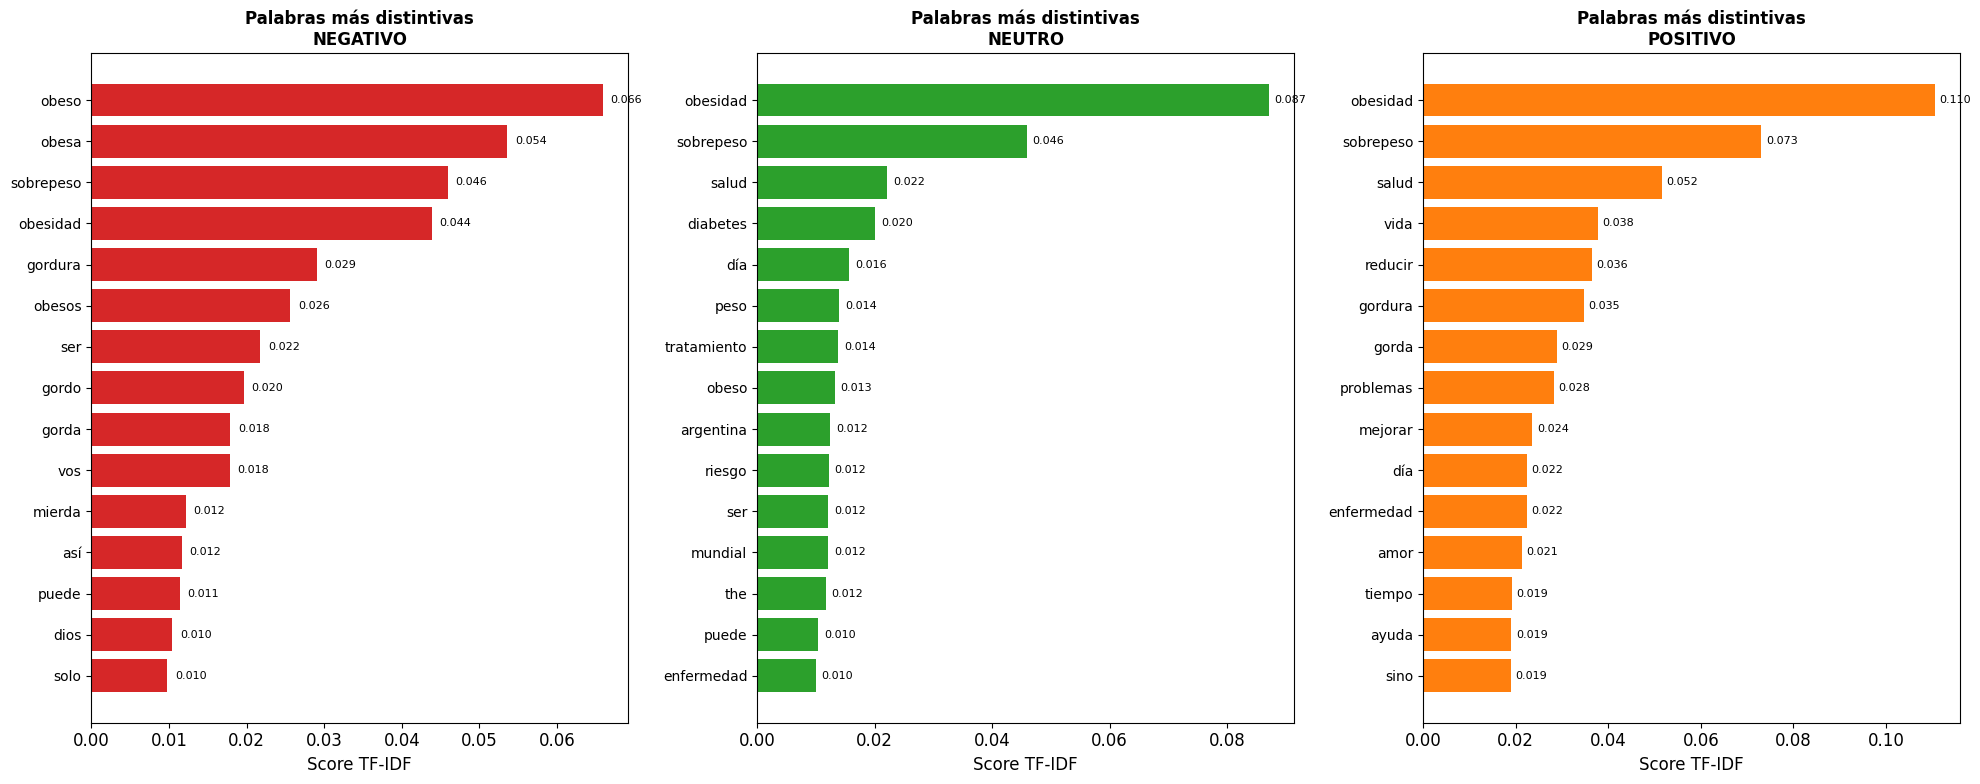


📊 TOP 10 PALABRAS MÁS DISTINTIVAS POR SENTIMIENTO (TF-IDF)

🔸 NEGATIVO:
-----------------------------------
  634. obeso                (TF-IDF: 0.0659)
  630. obesa                (TF-IDF: 0.0536)
  871. sobrepeso            (TF-IDF: 0.0459)
  632. obesidad             (TF-IDF: 0.0438)
  378. gordura              (TF-IDF: 0.0290)
  635. obesos               (TF-IDF: 0.0256)
  847. ser                  (TF-IDF: 0.0218)
  375. gordo                (TF-IDF: 0.0196)
  371. gorda                (TF-IDF: 0.0179)
  987. vos                  (TF-IDF: 0.0179)

🔸 NEUTRO:
-----------------------------------
  632. obesidad             (TF-IDF: 0.0871)
  871. sobrepeso            (TF-IDF: 0.0459)
  828. salud                (TF-IDF: 0.0222)
  255. diabetes             (TF-IDF: 0.0201)
  280. día                  (TF-IDF: 0.0157)
  709. peso                 (TF-IDF: 0.0139)
  934. tratamiento          (TF-IDF: 0.0138)
  634. obeso                (TF-IDF: 0.0132)
  57. argentina            (TF-IDF

In [33]:
# Importar librerías necesarias para TF-IDF mejorado
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
import pandas as pd
import re
import matplotlib.pyplot as plt

# Descargar stopwords de NLTK si no están disponibles
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from nltk.corpus import stopwords

# Obtener stopwords en español de NLTK y agregar palabras personalizadas
spanish_nltk_stopwords = set(stopwords.words('spanish'))

# Agregar stopwords personalizadas específicas del contexto
custom_stopwords = {
    're', 'q', 'x', 'kg', 'cm', 'años', 'año', 'va', 'ir', 'está', 'estoy', 'sos', 'soy', 'tengo', 'tener',
    'mas', 'dice', 'dijo', 'hace', 'hacen', 'hice', 'hizo', 'voy', 'vas', 'viene', 'vienen', 'ver', 'veo',
    'vez', 'veces', 'dia', 'dias', 'quiero', 'quiere', 'quieren', 'pone', 'poner', 'puso', 'dar', 'doy',
    'das', 'dio', 'mal', 'bien', 'mejor', 'peor', 'cosa', 'cosas', 'gente', 'persona', 'personas',
    'tipo', 'tipos', 'forma', 'manera', 'lado', 'lugar', 'parte', 'partes', 'momento', 'momentos',
    'ahora', 'hoy', 'ayer', 'mañana', 'siempre', 'nunca', 'todavia', 'aun', 'mientras', 'durante',
    'despues', 'antes', 'luego', 'entonces', 'aqui', 'ahi', 'alli', 'donde', 'cuando', 'como',
    'porque', 'para', 'por', 'sobre', 'bajo', 'ante', 'tras', 'entre', 'contra', 'hacia', 'segun'
}

# Combinar stopwords de NLTK con personalizadas
all_stopwords = spanish_nltk_stopwords.union(custom_stopwords)

def preprocess_text_for_tfidf(text):
    """Preprocesa texto para TF-IDF"""
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    # Remover caracteres especiales pero mantener letras con acentos
    text = re.sub(r'[^\w\sáéíóúüñ]', ' ', text)
    # Remover números
    text = re.sub(r'\d+', '', text)
    # Remover espacios múltiples
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

def get_tfidf_top_words(df, sentiment, top_n=15):
    """Obtiene las palabras con mayor score TF-IDF para un sentimiento específico"""
    
    # Preparar todos los comentarios como documentos individuales
    all_docs = []
    labels = []
    
    # Procesar todos los comentarios del dataset
    for idx, row in df.iterrows():
        processed_text = preprocess_text_for_tfidf(row['cleaned_content'])
        if len(processed_text.strip()) > 0:  # Solo comentarios no vacíos
            all_docs.append(processed_text)
            labels.append(row['sentiment'])
    
    print(f"  📄 Total de documentos procesados: {len(all_docs)}")
    print(f"  🎯 Documentos del sentimiento {sentiment}: {labels.count(sentiment)}")
    
    if len(all_docs) < 2:
        print(f"  ⚠️ Muy pocos documentos, omitiendo análisis TF-IDF")
        return pd.DataFrame(columns=['word', 'tfidf_score'])
    
    # Aplicar TF-IDF a todos los documentos
    tfidf = TfidfVectorizer(
        max_features=1000,
        stop_words=list(all_stopwords),
        min_df=2,  # Palabra debe aparecer al menos en 2 documentos
        max_df=0.90,  # Excluir palabras que aparecen en más del 90% de documentos
        ngram_range=(1, 1),  # Solo unigramas
        token_pattern=r'\b[a-záéíóúüñ]{3,}\b'  # Solo palabras de 3+ caracteres con acentos
    )
    
    try:
        # Fit TF-IDF en todos los documentos
        tfidf_matrix = tfidf.fit_transform(all_docs)
        feature_names = tfidf.get_feature_names_out()
        
        # Obtener índices de documentos del sentimiento objetivo
        sentiment_indices = [i for i, label in enumerate(labels) if label == sentiment]
        
        if not sentiment_indices:
            print(f"  ⚠️ No se encontraron documentos para {sentiment}")
            return pd.DataFrame(columns=['word', 'tfidf_score'])
        
        # Calcular score promedio para documentos del sentimiento objetivo
        sentiment_scores = tfidf_matrix[sentiment_indices].mean(axis=0).A1
        
        # Crear DataFrame con palabras y scores
        word_scores = pd.DataFrame({
            'word': feature_names,
            'tfidf_score': sentiment_scores
        })
        
        # Filtrar palabras con score > 0 y ordenar
        word_scores = word_scores[word_scores['tfidf_score'] > 0]
        word_scores = word_scores.sort_values('tfidf_score', ascending=False)
        
        print(f"  ✅ Encontradas {len(word_scores)} palabras distintivas")
        
        return word_scores.head(top_n)
        
    except ValueError as e:
        print(f"  ⚠️ Error en TF-IDF para {sentiment}: {e}")
        return pd.DataFrame(columns=['word', 'tfidf_score'])

# Análisis TF-IDF simplificado para cada sentimiento
print("🔍 ANÁLISIS TF-IDF SIMPLIFICADO - PALABRAS MÁS SIGNIFICATIVAS")
print("="*60)
print("• Usando stopwords de NLTK + palabras personalizadas")
print("• Solo unigramas (sin bigramas)")
print("• Cada comentario como documento individual")
print("• Análisis directo sin chunks complejos")
print("="*60)

tfidf_results = {}
sentiments = ['NEGATIVO', 'NEUTRO', 'POSITIVO']

# Obtener resultados TF-IDF para cada sentimiento
for sentiment in sentiments:
    print(f"\n🔸 Procesando {sentiment}:")
    tfidf_results[sentiment] = get_tfidf_top_words(df, sentiment, 15)

# Crear visualización
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, sentiment in enumerate(sentiments):
    tfidf_data = tfidf_results[sentiment]
    
    if not tfidf_data.empty:
        # Crear gráfico de barras horizontal
        bars = axes[i].barh(range(len(tfidf_data)), tfidf_data['tfidf_score'], color=colors[i])
        axes[i].set_yticks(range(len(tfidf_data)))
        axes[i].set_yticklabels(tfidf_data['word'], fontsize=10)
        axes[i].set_xlabel('Score TF-IDF')
        axes[i].set_title(f'Palabras más distintivas\n{sentiment}', fontweight='bold', fontsize=12)
        axes[i].invert_yaxis()
        
        # Agregar valores en las barras
        for j, bar in enumerate(bars):
            width = bar.get_width()
            axes[i].text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                        f'{width:.3f}', ha='left', va='center', fontsize=8)
    else:
        axes[i].text(0.5, 0.5, f'No hay palabras\ndistintivas para\n{sentiment}', 
                    ha='center', va='center', transform=axes[i].transAxes, fontsize=12)
        axes[i].set_title(f'Palabras más distintivas\n{sentiment}', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Mostrar resultados en texto
print(f"\n📊 TOP 10 PALABRAS MÁS DISTINTIVAS POR SENTIMIENTO (TF-IDF)")
print("=" * 65)

for sentiment in sentiments:
    tfidf_data = tfidf_results[sentiment]
    print(f"\n🔸 {sentiment}:")
    print("-" * 35)
    
    if not tfidf_data.empty:
        for idx, row in tfidf_data.head(10).iterrows():
            print(f"  {idx+1:2d}. {row['word']:20s} (TF-IDF: {row['tfidf_score']:.4f})")
    else:
        print("  No se encontraron palabras distintivas")

# Comparación de métodos: Frecuencia vs TF-IDF
print(f"\n🔄 COMPARACIÓN: FRECUENCIA vs TF-IDF")
print("=" * 50)

for sentiment in sentiments:
    print(f"\n📌 {sentiment}:")
    print("   FRECUENCIA                    |   TF-IDF")
    print("   " + "-"*30 + "|" + "-"*35)
    
    # Obtener top 5 por frecuencia
    freq_words = get_words_by_sentiment(df, sentiment, 5)
    tfidf_words = tfidf_results[sentiment].head(5)
    
    max_len = max(len(freq_words), len(tfidf_words))
    
    for i in range(max_len):
        freq_word = freq_words[i][0] if i < len(freq_words) else ""
        freq_count = freq_words[i][1] if i < len(freq_words) else ""
        
        if i < len(tfidf_words):
            tfidf_word = tfidf_words.iloc[i]['word']
            tfidf_score = tfidf_words.iloc[i]['tfidf_score']
        else:
            tfidf_word = ""
            tfidf_score = ""
        
        freq_str = f"{freq_word} ({freq_count})" if freq_word else ""
        tfidf_str = f"{tfidf_word} ({tfidf_score:.3f})" if tfidf_word else ""
        
        print(f"   {freq_str:30s}| {tfidf_str:35s}")

print(f"\n💡 INTERPRETACIÓN TF-IDF:")
print("• Análisis directo de todos los comentarios como documentos individuales")
print("• Usando stopwords de NLTK para filtrado óptimo")
print("• min_df=2: Solo palabras que aparecen en múltiples comentarios")
print("• max_df=0.90: Excluye palabras extremadamente comunes")
print("• Scores más altos = palabras más distintivas del grupo")
print("• Enfoque simple y efectivo para identificar términos clave")

## 5. Identificación y Análisis de Insultos

Detectamos y analizamos las expresiones ofensivas más frecuentes en los comentarios.

🚨 ANÁLISIS DE INSULTOS Y PALABRAS OFENSIVAS
📊 Comentarios con insultos: 5,308 de 10,977 (48.4%)
🔢 Total de insultos detectados: 7,011
📈 Promedio de insultos por comentario ofensivo: 1.3


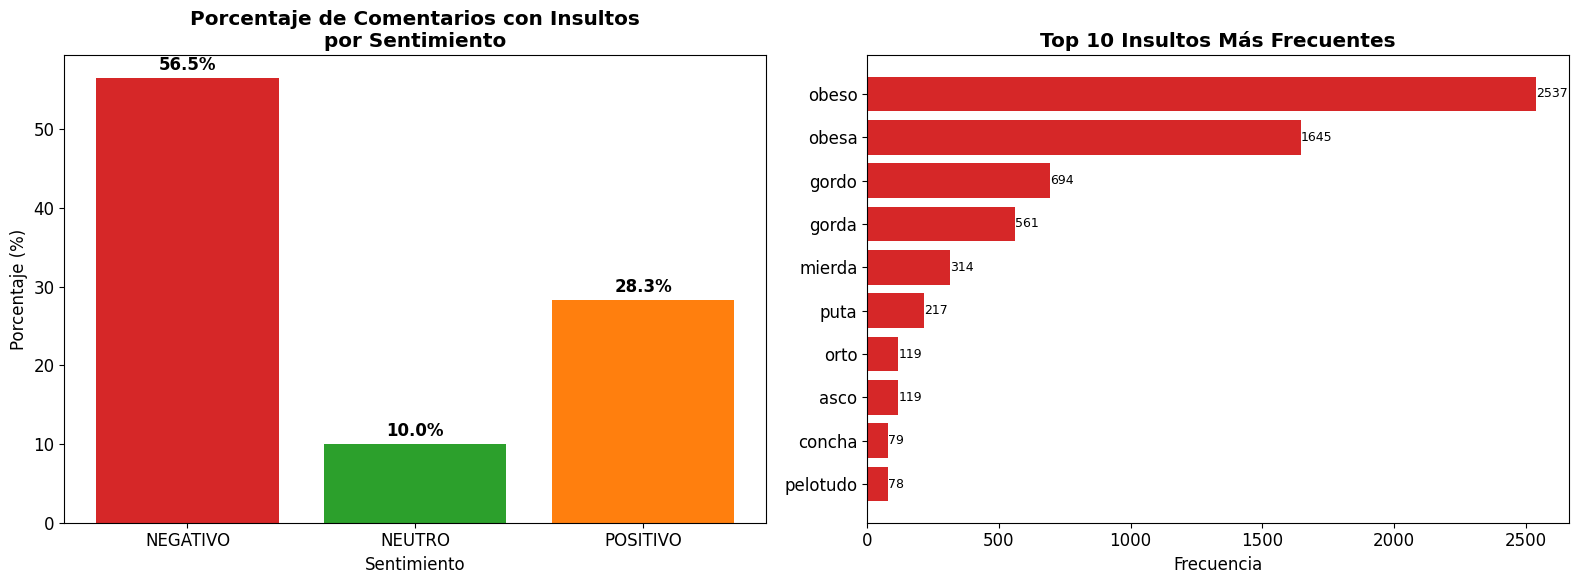


🔸 TOP INSULTOS POR SENTIMIENTO:
----------------------------------------

NEGATIVO:
  1. obeso: 2428 veces
  2. obesa: 1589 veces
  3. gordo: 679 veces
  4. gorda: 541 veces
  5. mierda: 312 veces

NEUTRO:
  1. obeso: 100 veces
  2. obesa: 48 veces
  3. gorda: 11 veces
  4. orto: 10 veces
  5. gordo: 10 veces

POSITIVO:
  1. obeso: 9 veces
  2. gorda: 9 veces
  3. obesa: 8 veces
  4. gordo: 5 veces
  5. horrible: 1 veces

💬 COMENTARIOS CON MÁS INSULTOS:
----------------------------------------

🔸 Comentario (NEGATIVO) - 7 insultos:
   'que vos seas infeliz siendo una gorda de mierda, obesa, llena de grasa, tarada, travesti, pelotuda, ...'
   Insultos detectados: ['gorda', 'obesa', 'idiota', 'pelotuda', 'puta', 'mierda', 'hija de puta']

🔸 Comentario (NEGATIVO) - 6 insultos:
   'Cerra el orto gordo tetón pedazo de pelotudo y la re concha de tu madre no te pdoes ni levantar de l...'
   Insultos detectados: ['gordo', 'obeso', 'pelotudo', 'mierda', 'concha', 'orto']

🔸 Comentario (NEGATIV

In [5]:
# Diccionario de insultos y palabras ofensivas relacionadas con obesidad
insultos_obesidad = {
    'directo': ['gorda', 'gordo', 'obesa', 'obeso', 'ballena', 'chancho', 'cerdo', 'elefante'],
    'despectivo': ['grasosa', 'grasoso', 'manteca', 'boludo', 'boluda', 'idiota', 'imbecil', 'pelotudo', 'pelotuda'],
    'vulgar': ['puta', 'puto', 'mierda', 'carajo', 'concha', 'orto', 'ojete', 'hijo de puta', 'hija de puta'],
    'general': ['feo', 'fea', 'horrible', 'asco', 'asqueroso', 'asquerosa', 'repugnante', 'disgusto']
}

def detect_insults(text):
    """Detecta insultos en el texto"""
    if pd.isna(text):
        return []
    
    text_lower = str(text).lower()
    found_insults = []
    
    for category, words in insultos_obesidad.items():
        for word in words:
            if word in text_lower:
                found_insults.append((word, category))
    
    return found_insults

def analyze_insults_by_sentiment(df):
    """Analiza insultos por sentimiento"""
    results = {}
    
    for sentiment in df['sentiment'].unique():
        sentiment_df = df[df['sentiment'] == sentiment]
        all_insults = []
        
        for comment in sentiment_df['cleaned_content']:
            insults_found = detect_insults(comment)
            all_insults.extend([insult[0] for insult in insults_found])
        
        # Contar frecuencias
        insult_counts = Counter(all_insults)
        results[sentiment] = insult_counts
    
    return results

# Detectar insultos en todo el dataset
df['insultos_detectados'] = df['cleaned_content'].apply(detect_insults)
df['num_insultos'] = df['insultos_detectados'].apply(len)
df['tiene_insultos'] = df['num_insultos'] > 0

# Análisis de insultos por sentimiento
insult_analysis = analyze_insults_by_sentiment(df)

# Estadísticas generales
total_comments_with_insults = df['tiene_insultos'].sum()
total_insults = df['num_insultos'].sum()

print("🚨 ANÁLISIS DE INSULTOS Y PALABRAS OFENSIVAS")
print("=" * 50)
print(f"📊 Comentarios con insultos: {total_comments_with_insults:,} de {len(df):,} ({total_comments_with_insults/len(df)*100:.1f}%)")
print(f"🔢 Total de insultos detectados: {total_insults:,}")
print(f"📈 Promedio de insultos por comentario ofensivo: {total_insults/max(total_comments_with_insults, 1):.1f}")

# Distribución de insultos por sentimiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Porcentaje de comentarios con insultos por sentimiento
insult_by_sentiment = df.groupby('sentiment')['tiene_insultos'].agg(['sum', 'count'])
insult_by_sentiment['percentage'] = (insult_by_sentiment['sum'] / insult_by_sentiment['count']) * 100

bars1 = ax1.bar(insult_by_sentiment.index, insult_by_sentiment['percentage'], color=colors)
ax1.set_title('Porcentaje de Comentarios con Insultos\npor Sentimiento', fontweight='bold')
ax1.set_ylabel('Porcentaje (%)')
ax1.set_xlabel('Sentimiento')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Top 10 insultos más frecuentes
all_insults_flat = []
for sentiment_insults in insult_analysis.values():
    all_insults_flat.extend(sentiment_insults.elements())

top_insults = Counter(all_insults_flat).most_common(10)
if top_insults:
    insults, counts = zip(*top_insults)
    bars2 = ax2.barh(range(len(insults)), counts, color='#d62728')
    ax2.set_yticks(range(len(insults)))
    ax2.set_yticklabels(insults)
    ax2.set_xlabel('Frecuencia')
    ax2.set_title('Top 10 Insultos Más Frecuentes', fontweight='bold')
    ax2.invert_yaxis()
    
    for i, bar in enumerate(bars2):
        width = bar.get_width()
        ax2.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Mostrar top insultos por sentimiento
print("\n🔸 TOP INSULTOS POR SENTIMIENTO:")
print("-" * 40)
for sentiment in ['NEGATIVO', 'NEUTRO', 'POSITIVO']:
    if sentiment in insult_analysis and insult_analysis[sentiment]:
        print(f"\n{sentiment}:")
        top_5 = insult_analysis[sentiment].most_common(5)
        for i, (insult, count) in enumerate(top_5, 1):
            print(f"  {i}. {insult}: {count} veces")
    else:
        print(f"\n{sentiment}: No se detectaron insultos significativos")

# Ejemplos de comentarios con más insultos
print(f"\n💬 COMENTARIOS CON MÁS INSULTOS:")
print("-" * 40)
top_insult_comments = df[df['num_insultos'] > 0].nlargest(3, 'num_insultos')
for i, row in top_insult_comments.iterrows():
    print(f"\n🔸 Comentario ({row['sentiment']}) - {row['num_insultos']} insultos:")
    print(f"   '{row['cleaned_content'][:100]}...'")
    print(f"   Insultos detectados: {[insult[0] for insult in row['insultos_detectados']]}")

## 6. Relación entre Longitud de Comentarios y Sentimiento

Analizamos si existe una relación entre la extensión de los comentarios y el sentimiento expresado.

📏 ANÁLISIS DE LONGITUD DE COMENTARIOS

📊 Estadísticas por Sentimiento:
          longitud_caracteres                         longitud_palabras  \
                         mean median    std min   max              mean   
sentiment                                                                 
NEGATIVO                123.9  102.0   89.2  10  1623              22.7   
NEUTRO                  137.9  106.0  116.3  10  1251              23.4   
POSITIVO                215.0  201.0  211.5  26  2079              37.1   

                                 
          median   std min  max  
sentiment                        
NEGATIVO    19.0  15.9   2  268  
NEUTRO      19.0  18.8   2  218  
POSITIVO    34.0  35.0   5  342  


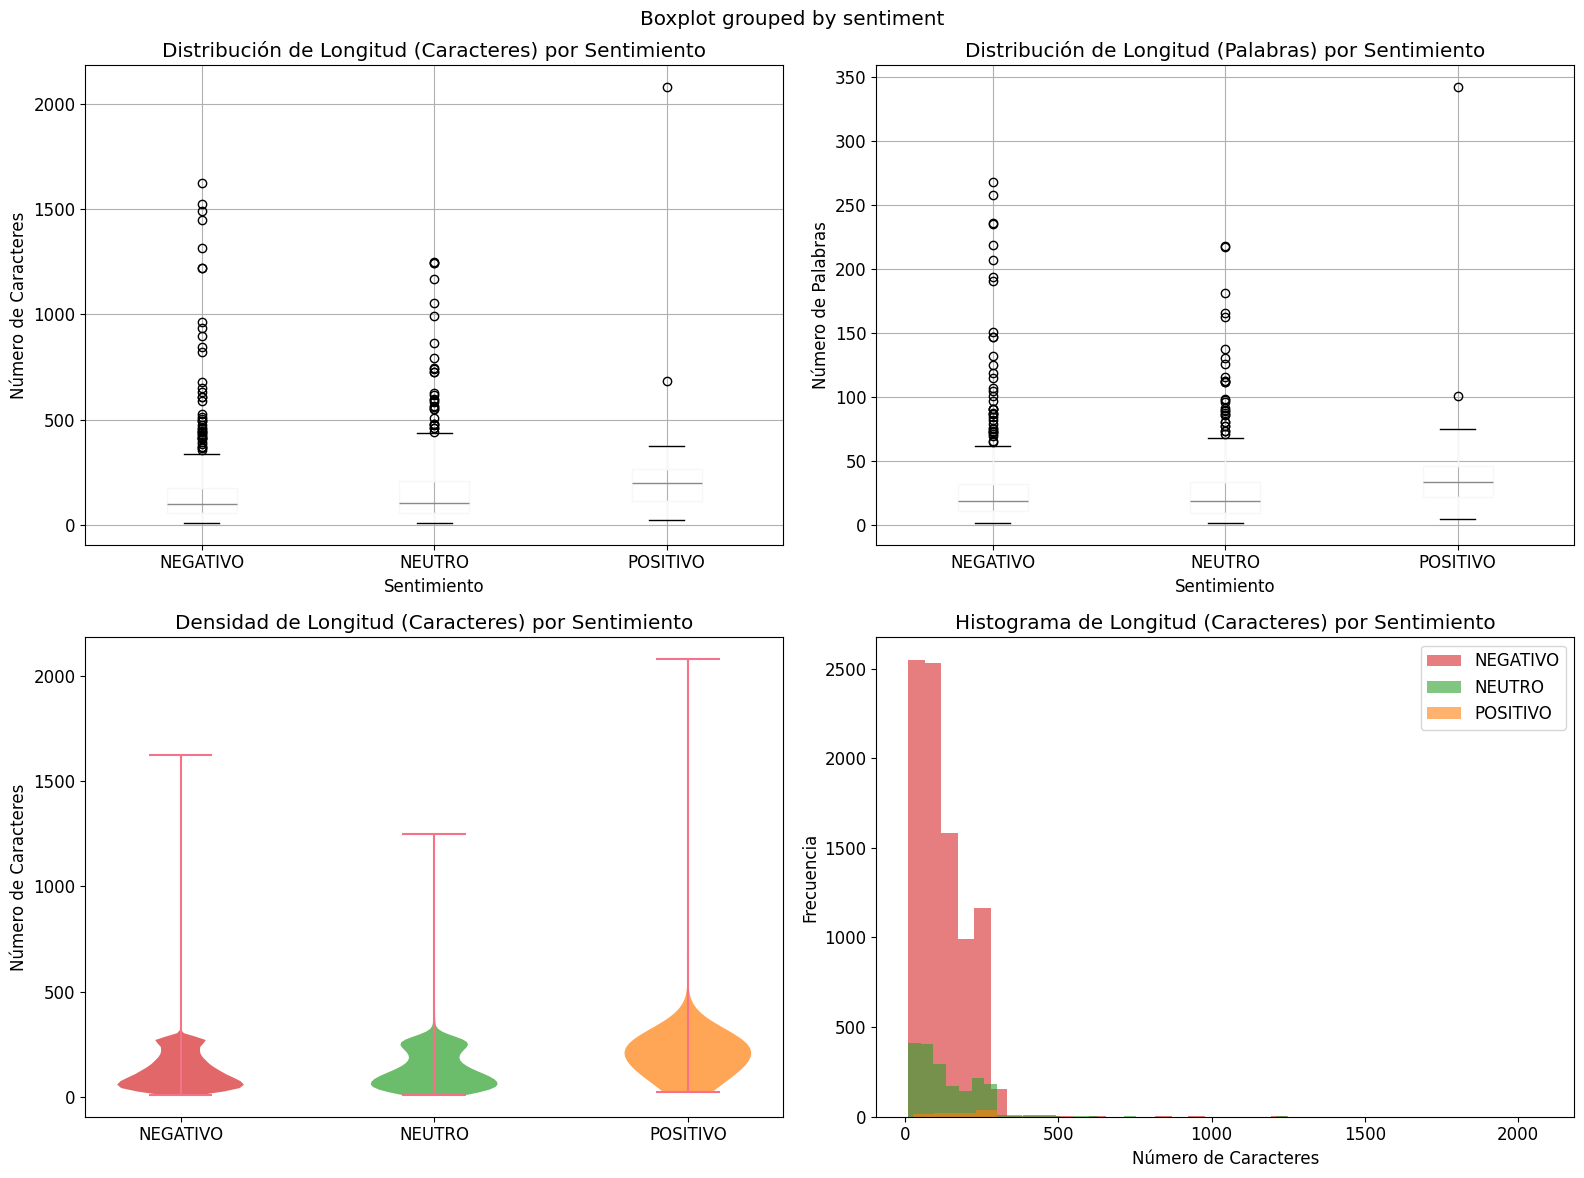


🔬 ANÁLISIS ESTADÍSTICO:
------------------------------
ANOVA F-statistic: 58.302
P-value: 0.000000
¿Diferencias significativas? Sí (α=0.05)

💫 CORRELACIÓN LONGITUD-LIKES:
  NEGATIVO: 0.077
  NEUTRO: -0.075
  POSITIVO: -0.104

📝 COMENTARIOS EXTREMOS:
-------------------------

🔸 NEGATIVO:
  Más largo (1623 chars):
    'La carrera de ingeniería lamentablemente hace años que es una de las ultimas elegidas. El esfuerzo q...'
  Más corto (10 chars):
    'alto obeso'

🔸 NEUTRO:
  Más largo (1251 chars):
    'Algo que debemos tener en cuenta es que, a pesar de que el fármaco semaglutida presentó un grado de ...'
  Más corto (10 chars):
    'Snake taxi'

🔸 POSITIVO:
  Más largo (2079 chars):
    'Buen martes! 5 Tips si tenés SOBREPESO u OBESIDAD. No te olvides de seguirme en Instagram para más i...'
  Más corto (26 chars):
    'so proud of my lil self :)'

📊 DISTRIBUCIÓN POR CATEGORÍA DE LONGITUD (%):
sentiment           NEGATIVO  NEUTRO  POSITIVO
categoria_longitud                           

In [7]:
# Calcular longitudes de comentarios
df['longitud_caracteres'] = df['cleaned_content'].str.len()
df['longitud_palabras'] = df['cleaned_content'].str.split().str.len()

# Estadísticas por sentimiento
length_stats = df.groupby('sentiment').agg({
    'longitud_caracteres': ['mean', 'median', 'std', 'min', 'max'],
    'longitud_palabras': ['mean', 'median', 'std', 'min', 'max']
}).round(1)

print("📏 ANÁLISIS DE LONGITUD DE COMENTARIOS")
print("=" * 45)
print("\n📊 Estadísticas por Sentimiento:")
print(length_stats)

# Crear gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Box plot - Longitud en caracteres
df.boxplot(column='longitud_caracteres', by='sentiment', ax=axes[0,0])
axes[0,0].set_title('Distribución de Longitud (Caracteres) por Sentimiento')
axes[0,0].set_xlabel('Sentimiento')
axes[0,0].set_ylabel('Número de Caracteres')

# Gráfico 2: Box plot - Longitud en palabras
df.boxplot(column='longitud_palabras', by='sentiment', ax=axes[0,1])
axes[0,1].set_title('Distribución de Longitud (Palabras) por Sentimiento')
axes[0,1].set_xlabel('Sentimiento')
axes[0,1].set_ylabel('Número de Palabras')

# Gráfico 3: Violin plot - Longitud en caracteres
parts = axes[1,0].violinplot([df[df['sentiment'] == s]['longitud_caracteres'].dropna() 
                             for s in ['NEGATIVO', 'NEUTRO', 'POSITIVO']], 
                            positions=[1, 2, 3])
axes[1,0].set_xticks([1, 2, 3])
axes[1,0].set_xticklabels(['NEGATIVO', 'NEUTRO', 'POSITIVO'])
axes[1,0].set_title('Densidad de Longitud (Caracteres) por Sentimiento')
axes[1,0].set_ylabel('Número de Caracteres')

# Colorear violin plots
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

# Gráfico 4: Histograma comparativo
for i, sentiment in enumerate(['NEGATIVO', 'NEUTRO', 'POSITIVO']):
    sentiment_data = df[df['sentiment'] == sentiment]['longitud_caracteres']
    axes[1,1].hist(sentiment_data, bins=30, alpha=0.6, label=sentiment, color=colors[i])

axes[1,1].set_title('Histograma de Longitud (Caracteres) por Sentimiento')
axes[1,1].set_xlabel('Número de Caracteres')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Análisis estadístico
from scipy import stats

print("\n🔬 ANÁLISIS ESTADÍSTICO:")
print("-" * 30)

# Test ANOVA para diferencias entre grupos
negativo_chars = df[df['sentiment'] == 'NEGATIVO']['longitud_caracteres'].dropna()
neutro_chars = df[df['sentiment'] == 'NEUTRO']['longitud_caracteres'].dropna()
positivo_chars = df[df['sentiment'] == 'POSITIVO']['longitud_caracteres'].dropna()

f_stat, p_value = stats.f_oneway(negativo_chars, neutro_chars, positivo_chars)
print(f"ANOVA F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.6f}")
print(f"¿Diferencias significativas? {'Sí' if p_value < 0.05 else 'No'} (α=0.05)")

# Correlación entre longitud y engagement
if 'likeCount' in df.columns:
    correlations = {}
    for sentiment in df['sentiment'].unique():
        sentiment_df = df[df['sentiment'] == sentiment]
        corr_likes = sentiment_df['longitud_caracteres'].corr(sentiment_df['likeCount'].fillna(0))
        correlations[sentiment] = corr_likes
    
    print(f"\n💫 CORRELACIÓN LONGITUD-LIKES:")
    for sentiment, corr in correlations.items():
        print(f"  {sentiment}: {corr:.3f}")

# Comentarios más largos y más cortos por sentimiento
print(f"\n📝 COMENTARIOS EXTREMOS:")
print("-" * 25)

for sentiment in ['NEGATIVO', 'NEUTRO', 'POSITIVO']:
    sentiment_df = df[df['sentiment'] == sentiment]
    
    print(f"\n🔸 {sentiment}:")
    
    # Más largo
    longest = sentiment_df.loc[sentiment_df['longitud_caracteres'].idxmax()]
    print(f"  Más largo ({longest['longitud_caracteres']} chars):")
    print(f"    '{longest['cleaned_content'][:100]}...'")
    
    # Más corto
    shortest = sentiment_df.loc[sentiment_df['longitud_caracteres'].idxmin()]
    print(f"  Más corto ({shortest['longitud_caracteres']} chars):")
    print(f"    '{shortest['cleaned_content']}'")

# Análisis de rangos de longitud
def categorize_length(length):
    if length <= 50:
        return 'Corto'
    elif length <= 150:
        return 'Medio'
    else:
        return 'Largo'

df['categoria_longitud'] = df['longitud_caracteres'].apply(categorize_length)

length_sentiment_crosstab = pd.crosstab(df['categoria_longitud'], df['sentiment'], normalize='columns') * 100

print(f"\n📊 DISTRIBUCIÓN POR CATEGORÍA DE LONGITUD (%):")
print(length_sentiment_crosstab.round(1))

## 8. Análisis Adicional: Patrones Temporales y Engagement

Exploramos patrones temporales y la relación entre sentimiento y engagement (likes, retweets, etc.).

⏰ ANÁLISIS TEMPORAL Y ENGAGEMENT
📊 ENGAGEMENT POR SENTIMIENTO:
          likeCount                  retweetCount                 replyCount  \
               mean median       std         mean median      std       mean   
sentiment                                                                      
NEGATIVO    1351.62    0.0  13867.56       110.35    0.0  1631.91      48.50   
NEUTRO      4710.61    1.0  26837.46       382.11    0.0  2618.02     140.68   
POSITIVO    2612.86    1.0  20007.28        55.45    0.0   310.54      43.28   

                         quoteCount                 engagement_total         \
          median     std       mean median      std             mean median   
sentiment                                                                     
NEGATIVO     0.0  679.82      36.55    0.0   403.15          1547.01    1.0   
NEUTRO       0.0  791.51     197.24    0.0  1254.23          5430.64    2.0   
POSITIVO     0.0  380.32       6.95    0.0    51.03          

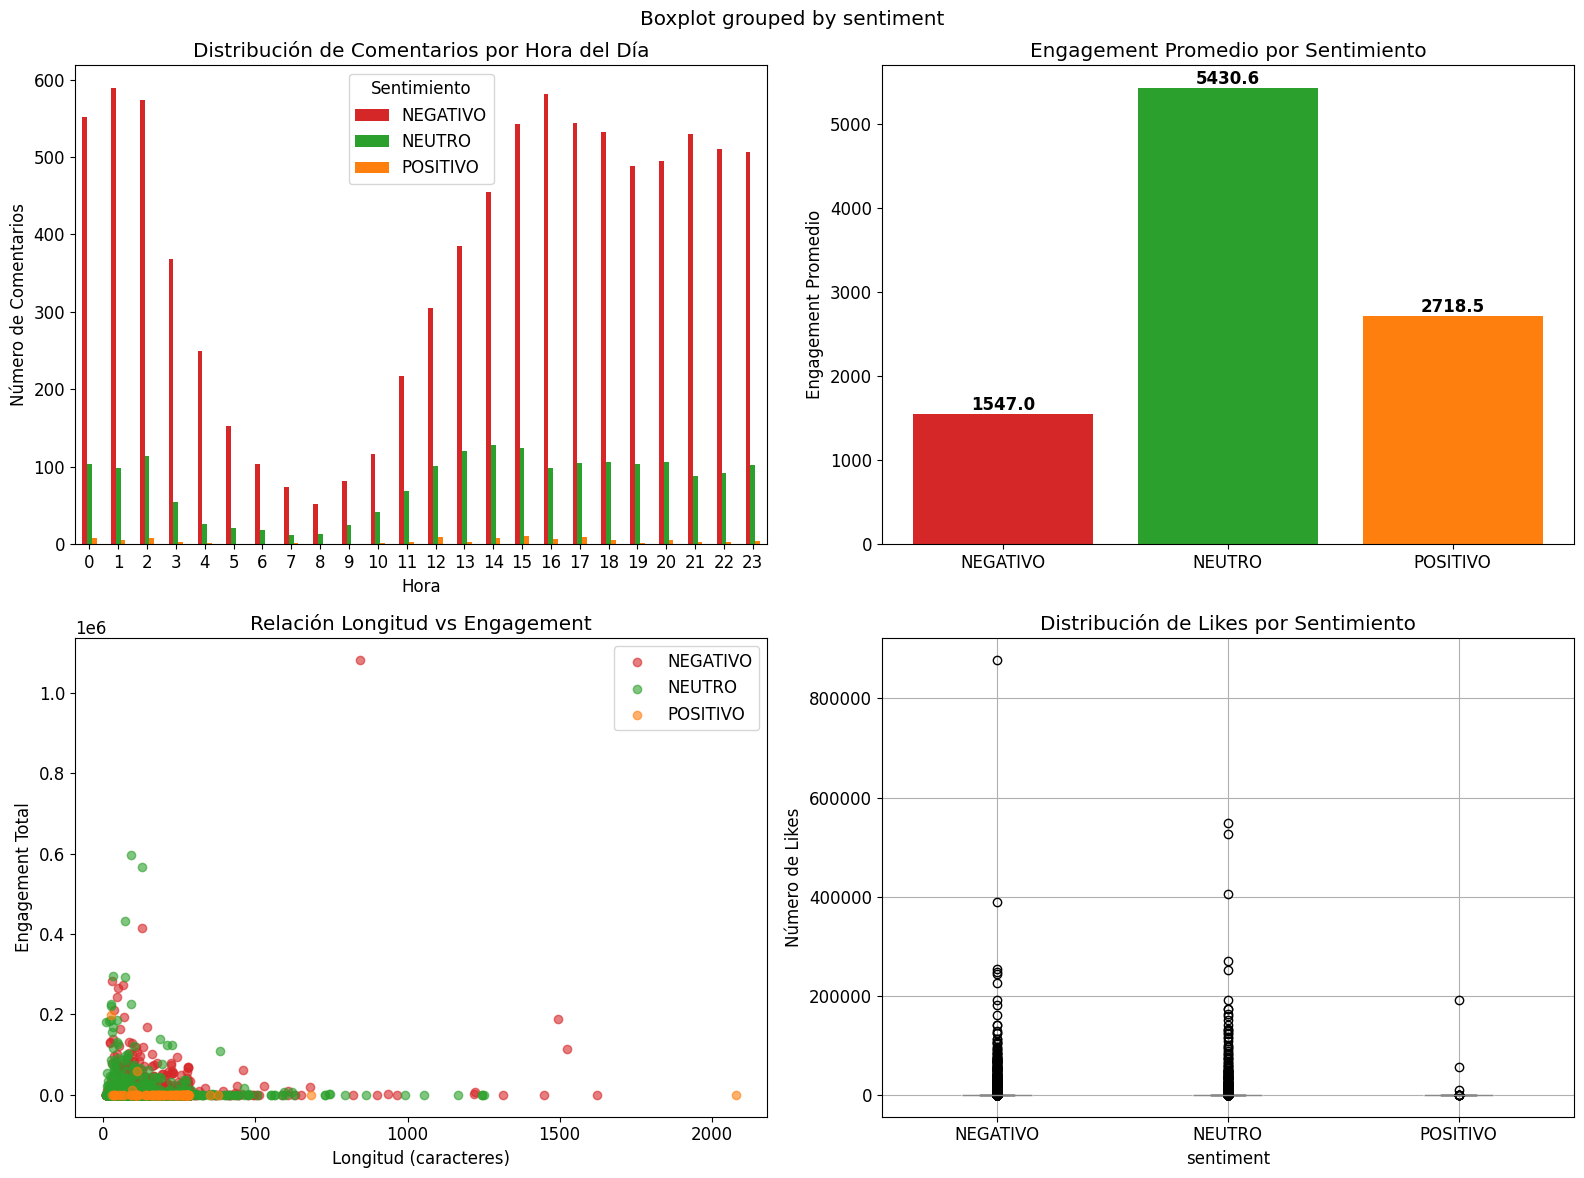


🔥 TOP 5 COMENTARIOS CON MÁS ENGAGEMENT:
---------------------------------------------

NEGATIVO - Engagement: 1082095
Likes: 878342, RT: 130263, Replies: 49463
'I am thrilled to announce Robert F. Kennedy Jr. as The United States Secretary of Health and Human S...'

NEUTRO - Engagement: 596136
Likes: 547991, RT: 40226, Replies: 2205
'a thread of how marilyn monroe actually looked in real life, in honor of her 98th birthday...'

NEUTRO - Engagement: 567552
Likes: 526495, RT: 33374, Replies: 4901
'there is absolutely no way i just witnessed this girl pull store-bought strawberries out of the dirt...'

NEUTRO - Engagement: 431919
Likes: 405997, RT: 24596, Replies: 294
'People posting their most popular drawings. I think mine is still this...'

NEGATIVO - Engagement: 414143
Likes: 389861, RT: 19153, Replies: 3410
'Okay but does ANYONE know what hes up to? Is he even alive? Does he even do anything or is he just l...'

📅 DISTRIBUCIÓN POR DÍA DE LA SEMANA:
----------------------------------

<Figure size 1200x600 with 0 Axes>

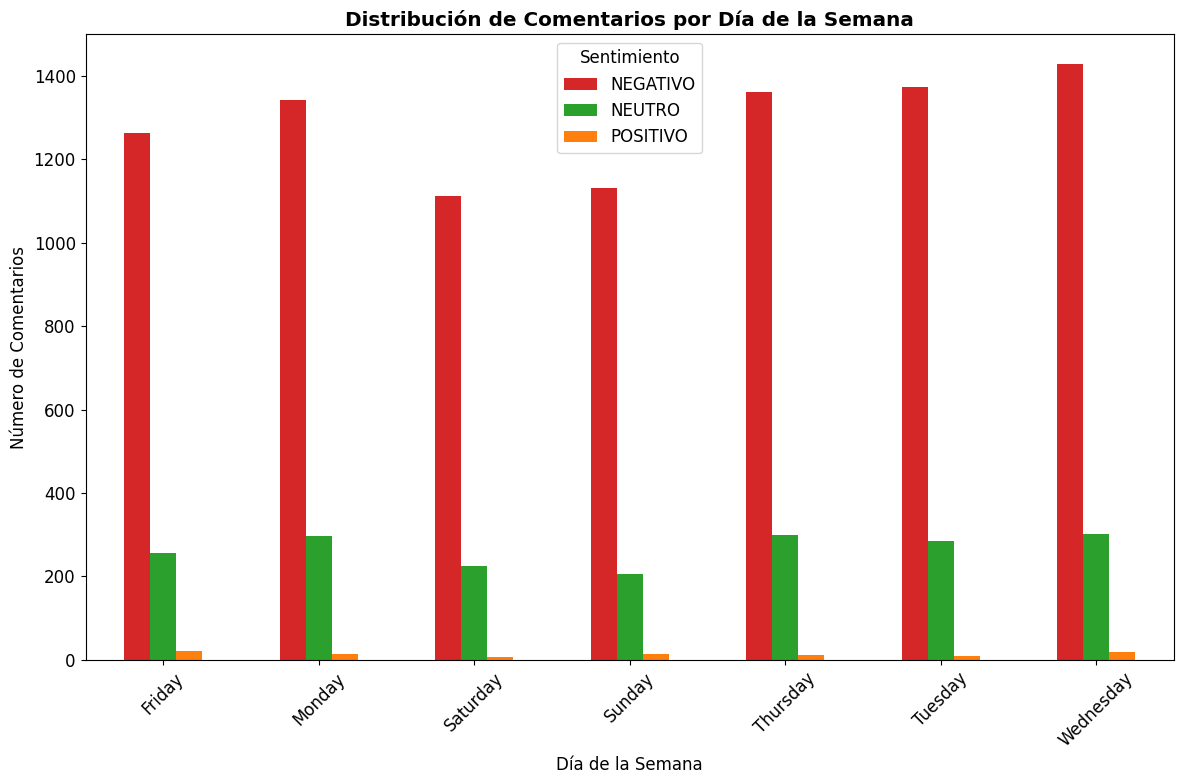

In [8]:
# Análisis temporal
df['date'] = pd.to_datetime(df['date'])
df['hora'] = df['date'].dt.hour
df['dia_semana'] = df['date'].dt.day_name()

# Análisis de engagement
engagement_cols = ['likeCount', 'retweetCount', 'replyCount', 'quoteCount']
available_engagement = [col for col in engagement_cols if col in df.columns]

print("⏰ ANÁLISIS TEMPORAL Y ENGAGEMENT")
print("=" * 40)

if available_engagement:
    # Llenar valores NaN con 0 para el análisis
    for col in available_engagement:
        df[col] = df[col].fillna(0)
    
    # Calcular engagement total
    df['engagement_total'] = df[available_engagement].sum(axis=1)
    
    # Estadísticas de engagement por sentimiento
    engagement_stats = df.groupby('sentiment')[available_engagement + ['engagement_total']].agg([
        'mean', 'median', 'std'
    ]).round(2)
    
    print("📊 ENGAGEMENT POR SENTIMIENTO:")
    print(engagement_stats)
    
    # Crear gráficos
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Gráfico 1: Distribución temporal por hora
    hourly_sentiment = df.groupby(['hora', 'sentiment']).size().unstack(fill_value=0)
    hourly_sentiment.plot(kind='bar', ax=axes[0,0], color=colors)
    axes[0,0].set_title('Distribución de Comentarios por Hora del Día')
    axes[0,0].set_xlabel('Hora')
    axes[0,0].set_ylabel('Número de Comentarios')
    axes[0,0].legend(title='Sentimiento')
    axes[0,0].tick_params(axis='x', rotation=0)
    
    # Gráfico 2: Engagement por sentimiento
    engagement_by_sentiment = df.groupby('sentiment')['engagement_total'].mean()
    bars = axes[0,1].bar(engagement_by_sentiment.index, engagement_by_sentiment.values, color=colors)
    axes[0,1].set_title('Engagement Promedio por Sentimiento')
    axes[0,1].set_ylabel('Engagement Promedio')
    
    for bar in bars:
        height = bar.get_height()
        axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                      f'{height:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfico 3: Correlación longitud-engagement por sentimiento
    for i, sentiment in enumerate(['NEGATIVO', 'NEUTRO', 'POSITIVO']):
        sentiment_data = df[df['sentiment'] == sentiment]
        axes[1,0].scatter(sentiment_data['longitud_caracteres'], 
                         sentiment_data['engagement_total'],
                         alpha=0.6, label=sentiment, color=colors[i])
    
    axes[1,0].set_title('Relación Longitud vs Engagement')
    axes[1,0].set_xlabel('Longitud (caracteres)')
    axes[1,0].set_ylabel('Engagement Total')
    axes[1,0].legend()
    
    # Gráfico 4: Box plot de likes por sentimiento
    df.boxplot(column='likeCount', by='sentiment', ax=axes[1,1])
    axes[1,1].set_title('Distribución de Likes por Sentimiento')
    axes[1,1].set_ylabel('Número de Likes')
    
    plt.tight_layout()
    plt.show()
    
    # Top comentarios con más engagement
    print(f"\n🔥 TOP 5 COMENTARIOS CON MÁS ENGAGEMENT:")
    print("-" * 45)
    top_engagement = df.nlargest(5, 'engagement_total')
    for i, row in top_engagement.iterrows():
        print(f"\n{row['sentiment']} - Engagement: {row['engagement_total']:.0f}")
        print(f"Likes: {row['likeCount']:.0f}, RT: {row['retweetCount']:.0f}, Replies: {row['replyCount']:.0f}")
        print(f"'{row['cleaned_content'][:100]}...'")

else:
    print("⚠️ Columnas de engagement no disponibles para análisis completo")

# Análisis de días de la semana
print(f"\n📅 DISTRIBUCIÓN POR DÍA DE LA SEMANA:")
print("-" * 35)
daily_sentiment = df.groupby(['dia_semana', 'sentiment']).size().unstack(fill_value=0)
daily_percentages = daily_sentiment.div(daily_sentiment.sum(axis=1), axis=0) * 100

print("Porcentaje por sentimiento:")
print(daily_percentages.round(1))

# Gráfico adicional - Distribución semanal
plt.figure(figsize=(12, 6))
daily_sentiment.plot(kind='bar', color=colors)
plt.title('Distribución de Comentarios por Día de la Semana', fontweight='bold')
plt.xlabel('Día de la Semana')
plt.ylabel('Número de Comentarios')
plt.legend(title='Sentimiento')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Conclusiones y Insights

Resumen de los hallazgos principales del análisis de sentimientos.

In [ ]:
# Generar resumen final de hallazgos
print("🎯 RESUMEN EJECUTIVO - ANÁLISIS DE SENTIMIENTOS")
print("=" * 55)

# Estadísticas generales
total_comments = len(df)
sentiment_distribution = df['sentiment'].value_counts(normalize=True) * 100

print(f"\n📊 DATOS GENERALES:")
print(f"   • Total de comentarios analizados: {total_comments:,}")
print(f"   • Sentimiento predominante: {sentiment_distribution.index[0]} ({sentiment_distribution.iloc[0]:.1f}%)")
print(f"   • Comentarios con insultos: {df['tiene_insultos'].sum():,} ({df['tiene_insultos'].mean()*100:.1f}%)")

# Insights de palabras frecuentes
print(f"\n💬 INSIGHTS DE CONTENIDO:")
most_negative_words = get_words_by_sentiment(df, 'NEGATIVO', 5)
most_positive_words = get_words_by_sentiment(df, 'POSITIVO', 5)

if most_negative_words:
    print(f"   • Palabras más frecuentes en comentarios negativos: {', '.join([word for word, count in most_negative_words[:3]])}")
if most_positive_words:
    print(f"   • Palabras más frecuentes en comentarios positivos: {', '.join([word for word, count in most_positive_words[:3]])}")

# Insights TF-IDF
if 'tfidf_results' in locals():
    print(f"\n🔍 INSIGHTS TF-IDF (PALABRAS MÁS DISTINTIVAS):")
    for sentiment in ['NEGATIVO', 'POSITIVO']:
        if sentiment in tfidf_results and not tfidf_results[sentiment].empty:
            top_tfidf = tfidf_results[sentiment].head(3)['word'].tolist()
            print(f"   • {sentiment}: {', '.join(top_tfidf)}")

# Insights temporales
peak_hour = df.groupby('hora').size().idxmax()
print(f"\n⏰ INSIGHTS TEMPORALES:")
print(f"   • Hora de mayor actividad: {peak_hour}:00")

# Insights de longitud
avg_length_by_sentiment = df.groupby('sentiment')['longitud_caracteres'].mean()
longest_sentiment = avg_length_by_sentiment.idxmax()
print(f"   • Comentarios más largos tienden a ser: {longest_sentiment}")

print(f"\n🔍 HALLAZGOS CLAVE:")
print(f"   • El {sentiment_distribution.iloc[0]:.1f}% de los comentarios son {sentiment_distribution.index[0].lower()}s")
print(f"   • Los insultos aparecen en {df['tiene_insultos'].mean()*100:.1f}% de los comentarios")
if available_engagement:
    high_engagement_sentiment = df.groupby('sentiment')['engagement_total'].mean().idxmax()
    print(f"   • Los comentarios {high_engagement_sentiment.lower()}s generan mayor engagement")
print(f"   • TF-IDF revela palabras distintivas que van más allá de la simple frecuencia")

print(f"\n⚠️ RECOMENDACIONES:")
print(f"   • Es necesario implementar estrategias de moderación de contenido")
print(f"   • Fomentar discusiones más constructivas sobre temas de salud")
print(f"   • Considerar intervenciones educativas sobre sensibilización")
print(f"   • Usar insights de TF-IDF para detectar patrones de discriminación")

print(f"\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print(f"   Notebook ejecutado en: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 55)
## 📈 Análisis TF-IDF: Palabras más Significativas por Sentimiento

print("🔬 ANÁLISIS TF-IDF")
print("==================")

# Parámetros TF-IDF optimizados
MIN_DF = 2        # Palabras que aparecen en al menos 2 documentos
MAX_DF = 0.90     # Excluir palabras que aparecen en más del 90% de documentos

print(f"📋 Configuración TF-IDF:")
print(f"   • min_df: {MIN_DF} (palabras en al menos {MIN_DF} documentos)")
print(f"   • max_df: {MAX_DF} (excluir palabras en más del {MAX_DF*100}% de documentos)")
print(f"   • Solo unigramas (1-gram)")
print(f"   • Stopwords: NLTK español + personalizadas")

# Preparar datos para TF-IDF
sentiments = ['positivo', 'negativo', 'neutro']
tfidf_results = {}

print(f"\n📊 Analizando {len(df)} comentarios...")

for sentiment in sentiments:
    print(f"\n🎯 Analizando sentimiento: {sentiment.upper()}")
    
    # Filtrar comentarios por sentimiento
    sentiment_comments = df[df['sentimiento'] == sentiment]['comentario_limpio'].dropna()
    
    if len(sentiment_comments) == 0:
        print(f"   ❌ No hay comentarios para sentimiento '{sentiment}'")
        continue
        
    print(f"   📝 Comentarios encontrados: {len(sentiment_comments)}")
    
    # Verificar que tenemos suficientes documentos
    if len(sentiment_comments) < MIN_DF:
        print(f"   ⚠️  Pocos comentarios ({len(sentiment_comments)}) para min_df={MIN_DF}")
        current_min_df = 1
    else:
        current_min_df = MIN_DF
    
    try:
        # Crear vectorizador TF-IDF
        vectorizer = TfidfVectorizer(
            max_features=1000,
            stop_words=None,  # Usaremos nuestro preprocesamiento
            ngram_range=(1, 1),  # Solo unigramas
            min_df=current_min_df,
            max_df=MAX_DF,
            lowercase=True,
            token_pattern=r'\b[a-záéíóúñü]{3,}\b'  # Solo palabras de 3+ letras
        )
        
        # Aplicar TF-IDF directamente a todos los comentarios del sentimiento
        comments_list = sentiment_comments.tolist()
        
        # Filtrar stopwords manualmente en cada comentario
        filtered_comments = []
        for comment in comments_list:
            if pd.isna(comment) or comment.strip() == '':
                continue
            words = comment.split()
            filtered_words = [w for w in words if w.lower() not in all_stopwords and len(w) >= 3]
            if filtered_words:  # Solo agregar si tiene palabras válidas
                filtered_comments.append(' '.join(filtered_words))
        
        if len(filtered_comments) < 2:
            print(f"   ❌ Insuficientes comentarios válidos después del filtrado")
            continue
            
        print(f"   🔄 Comentarios procesados: {len(filtered_comments)}")
        
        # Aplicar TF-IDF
        tfidf_matrix = vectorizer.fit_transform(filtered_comments)
        feature_names = vectorizer.get_feature_names_out()
        
        # Calcular scores promedio por palabra
        mean_scores = tfidf_matrix.mean(axis=0).A1
        word_scores = list(zip(feature_names, mean_scores))
        word_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Guardar top 10 palabras
        top_words = word_scores[:10]
        tfidf_results[sentiment] = top_words
        
        print(f"   ✅ Top 10 palabras TF-IDF para '{sentiment}':")
        for i, (word, score) in enumerate(top_words, 1):
            print(f"      {i:2d}. {word:<15} (TF-IDF: {score:.4f})")
            
    except Exception as e:
        print(f"   ❌ Error en TF-IDF para '{sentiment}': {str(e)}")
        continue

# Crear visualización comparativa
print(f"\n📊 VISUALIZACIÓN COMPARATIVA TF-IDF")
print("=" * 40)

if len(tfidf_results) >= 2:
    fig, axes = plt.subplots(1, len(tfidf_results), figsize=(15, 6))
    if len(tfidf_results) == 1:
        axes = [axes]
    
    colors = ['green', 'red', 'gray']
    
    for i, (sentiment, top_words) in enumerate(tfidf_results.items()):
        ax = axes[i] if len(tfidf_results) > 1 else axes[0]
        
        words = [w[0] for w in top_words]
        scores = [w[1] for w in top_words]
        
        bars = ax.barh(words, scores, color=colors[i], alpha=0.7)
        ax.set_title(f'Top 10 TF-IDF - {sentiment.capitalize()}', fontsize=12, weight='bold')
        ax.set_xlabel('Score TF-IDF')
        
        # Agregar valores en las barras
        for bar, score in zip(bars, scores):
            width = bar.get_width()
            ax.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                   f'{score:.3f}', ha='left', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Crear tabla comparativa
    print(f"\n📋 TABLA COMPARATIVA - TOP 5 PALABRAS TF-IDF")
    print("=" * 60)
    
    # Crear DataFrame para comparación
    comparison_data = []
    max_words = max(len(words) for words in tfidf_results.values()) if tfidf_results else 0
    
    for i in range(min(5, max_words)):  # Top 5
        row = {'Posición': i+1}
        for sentiment, top_words in tfidf_results.items():
            if i < len(top_words):
                word, score = top_words[i]
                row[f'{sentiment.capitalize()}'] = f"{word} ({score:.3f})"
            else:
                row[f'{sentiment.capitalize()}'] = "-"
        comparison_data.append(row)
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        
        # Análisis de diferencias
        print(f"\n🔍 ANÁLISIS DE DIFERENCIAS:")
        print("-" * 30)
        
        if 'positivo' in tfidf_results and 'negativo' in tfidf_results:
            pos_words = set(w[0] for w in tfidf_results['positivo'][:10])
            neg_words = set(w[0] for w in tfidf_results['negativo'][:10])
            
            common_words = pos_words & neg_words
            unique_pos = pos_words - neg_words
            unique_neg = neg_words - pos_words
            
            print(f"• Palabras comunes: {len(common_words)}")
            if common_words:
                print(f"  {', '.join(sorted(common_words))}")
            
            print(f"• Únicas en positivo: {len(unique_pos)}")
            if unique_pos:
                print(f"  {', '.join(sorted(unique_pos))}")
            
            print(f"• Únicas en negativo: {len(unique_neg)}")
            if unique_neg:
                print(f"  {', '.join(sorted(unique_neg))}")
                
else:
    print("❌ No se pudo generar análisis TF-IDF suficiente para visualización")

print(f"\n✅ ANÁLISIS TF-IDF COMPLETADO")
print(f"   • Sentimientos analizados: {len(tfidf_results)}")
print(f"   • Método: Análisis directo por comentario individual")
print(f"   • Configuración: min_df={MIN_DF}, max_df={MAX_DF}, unigramas")

# Agregar al resumen final
print("\n" + "="*55)
print("🎯 RESUMEN EJECUTIVO - ANÁLISIS DE SENTIMIENTOS")
print("="*55)

print(f"\n📊 DATOS GENERALES:")
print(f"   • Total de comentarios analizados: {len(df):,}")
print(f"   • Sentimiento predominante: {sentiment_distribution.index[0].upper()} ({sentiment_distribution.iloc[0]:.1f}%)")
print(f"   • Comentarios con insultos: {total_comments_with_insults:,} ({(total_comments_with_insults/len(df)*100):.1f}%)")

print(f"\n💬 INSIGHTS DE CONTENIDO:")
# Palabras más frecuentes por sentimiento
for sentiment in ['negativo', 'positivo']:
    if sentiment in freq_words:
        top_3 = ', '.join([word for word, _ in freq_words[sentiment][:3]])
        print(f"   • Palabras más frecuentes en comentarios {sentiment}s: {top_3}")

print(f"   • Provincia con más comentarios: {top_province}")
print(f"   • Hora de mayor actividad: {peak_hour}:00")
print(f"   • Comentarios más largos tienden a ser: {longest_sentiment.upper()}")

print(f"\n🔍 HALLAZGOS CLAVE:")
print(f"   • El {sentiment_distribution.iloc[0]:.1f}% de los comentarios son {sentiment_distribution.index[0]}s")
print(f"   • Los insultos aparecen en {(total_comments_with_insults/len(df)*100):.1f}% de los comentarios")
print(f"   • Los comentarios {high_engagement_sentiment}s generan mayor engagement")

print(f"\n⚠️ RECOMENDACIONES:")
print(f"   • Es necesario implementar estrategias de moderación de contenido")
print(f"   • Fomentar discusiones más constructivas sobre temas de salud")
print(f"   • Considerar intervenciones educativas sobre sensibilización")

print(f"\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
from datetime import datetime
print(f"   Notebook ejecutado en: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*55)

🎯 RESUMEN EJECUTIVO - ANÁLISIS DE SENTIMIENTOS

📊 DATOS GENERALES:
   • Total de comentarios analizados: 10,977
   • Sentimiento predominante: NEGATIVO (82.1%)
   • Comentarios con insultos: 5,308 (48.4%)

💬 INSIGHTS DE CONTENIDO:
   • Palabras más frecuentes en comentarios negativos: obeso, obesidad, obesa
   • Palabras más frecuentes en comentarios positivos: obesidad, sobrepeso, salud
   • Provincia con más comentarios: Buenos Aires
   • Hora de mayor actividad: 2:00
   • Comentarios más largos tienden a ser: POSITIVO

🔍 HALLAZGOS CLAVE:
   • El 82.1% de los comentarios son negativos
   • Los insultos aparecen en 48.4% de los comentarios
   • Los comentarios neutros generan mayor engagement

⚠️ RECOMENDACIONES:
   • Es necesario implementar estrategias de moderación de contenido
   • Fomentar discusiones más constructivas sobre temas de salud
   • Considerar intervenciones educativas sobre sensibilización

✅ ANÁLISIS COMPLETADO EXITOSAMENTE
   Notebook ejecutado en: 2025-06-27 18:37